# Neural Network Experiments

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
import warnings

from sklearn.model_selection import cross_val_score, GroupKFold, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

from visualization_config import COLOR_PALETTE, setup_plot_style

warnings.filterwarnings('ignore')
setup_plot_style()
np.random.seed(42)

## Data Loading & Preprocessing

In [2]:
from data_loader import EEGDataLoader, get_default_data_path
from preprocessing import EEGPreprocessor, FeatureExtractor

data_path = get_default_data_path()
loader = EEGDataLoader(str(data_path))

summary_df = loader.create_summary_dataframe()
block_columns = ['honest_true', 'deceitful_true', 'honest_fake', 'deceitful_fake']
complete_participants = summary_df[summary_df[block_columns].all(axis=1)]
participants_to_use = complete_participants['participant_id'].tolist()

print(f"Found {len(participants_to_use)} participants with all 4 blocks")

Skipping excluded folder: 6A517891 - stare dane
Skipping excluded folder: Popsute dane - ASD793JD
Successfully loaded metadata with encoding: cp1250
Found 15 participants
Loaded metadata for 16 participants
Found 15 participants with all 4 blocks


In [3]:
cache_file = Path('results/ml_features_cache.pkl')

if cache_file.exists():
    print("Loading cached features...")
    with open(cache_file, 'rb') as f:
        cache = pickle.load(f)
    X = cache['X']
    y = cache['y']
    participant_ids = cache['participant_ids']
    print(f"Loaded from cache: {X.shape[0]} samples, {X.shape[1]} features")
else:
    print("No cache found, processing data with multiprocessing...")
    from concurrent.futures import ProcessPoolExecutor, as_completed
    import multiprocessing
    
    preprocessor = EEGPreprocessor(
        l_freq=0.5,
        h_freq=40.0,
        notch_freq=50.0, 
        epoch_tmin=-0.2, 
        epoch_tmax=0.8
    )
    feature_extractor = FeatureExtractor(sampling_freq=250.0)

    def process_participant(participant_id):
        """Process a single participant - for multiprocessing"""
        try:
            participant_data = loader.load_participant_data(participant_id)
            features_list = []
            labels_list = []
            
            for block_name, raw in participant_data.items():
                epochs = preprocessor.preprocess_pipeline(raw)
                if len(epochs) == 0:
                    continue
                features = feature_extractor.extract_combined_features(epochs)
                is_deceitful = 'deceitful' in block_name
                labels = np.ones(len(epochs)) if is_deceitful else np.zeros(len(epochs))
                features_list.append(features)
                labels_list.append(labels)
            
            if features_list:
                return {
                    'features': np.vstack(features_list),
                    'labels': np.concatenate(labels_list),
                    'participant_id': participant_id
                }
        except Exception as e:
            print(f"Error processing {participant_id}: {e}")
        return None

    all_features = []
    all_labels = []
    all_participants_ids = []

    for idx, participant_id in enumerate(participants_to_use, 1):
        print(f"\rProcessing {idx}/{len(participants_to_use)}: {participant_id}", end="")
        result = process_participant(participant_id)
        if result:
            all_features.append(result['features'])
            all_labels.append(result['labels'])
            all_participants_ids.extend([result['participant_id']] * len(result['labels']))

    X = np.vstack(all_features)
    y = np.concatenate(all_labels)
    participant_ids = np.array(all_participants_ids)

    cache_file.parent.mkdir(exist_ok=True)
    with open(cache_file, 'wb') as f:
        pickle.dump({'X': X, 'y': y, 'participant_ids': participant_ids}, f)
    print(f"\n\nCache saved to {cache_file}")

print(f"\nDataset ready!")
print(f"  Total samples: {X.shape[0]}")
print(f"  Features: {X.shape[1]}")
print(f"  Honest: {(y == 0).sum()} ({(y == 0).sum() / len(y) * 100:.1f}%)")
print(f"  Deceitful: {(y == 1).sum()} ({(y == 1).sum() / len(y) * 100:.1f}%)")

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nData standardized: {X_scaled.shape}")
print(f"Mean: {X_scaled.mean():.4f}, Std: {X_scaled.std():.4f}")

unique_participants = np.unique(participant_ids)
n_participants = len(unique_participants)
n_splits = min(5, n_participants // 2)
cv = GroupKFold(n_splits=n_splits)

print(f"\nUsing {n_splits}-fold GroupKFold (person-independent validation)")
print(f"Each fold tests on ~{n_participants // n_splits} different people")

Loading cached features...
Loaded from cache: 6463 samples, 252 features

Dataset ready!
  Total samples: 6463
  Features: 252
  Honest: 3223 (49.9%)
  Deceitful: 3240 (50.1%)

Data standardized: (6463, 250)
Mean: 0.0000, Std: 0.9612

Using 5-fold GroupKFold (person-independent validation)
Each fold tests on ~3 different people


## Model Architectures

### 1. Simple MLP Architecture

In [4]:
mlp_simple = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10
)

print(f"Architecture: {X_scaled.shape[1]} -> 100 -> 2")
print("(Input -> Hidden -> Output)")

print("\nRunning cross-validation...")
cv_scores = cross_val_score(mlp_simple, X_scaled, y, groups=participant_ids, cv=cv, scoring='accuracy')
cv_precision = cross_val_score(mlp_simple, X_scaled, y, groups=participant_ids, cv=cv, scoring='precision')
cv_recall = cross_val_score(mlp_simple, X_scaled, y, groups=participant_ids, cv=cv, scoring='recall')
cv_f1 = cross_val_score(mlp_simple, X_scaled, y, groups=participant_ids, cv=cv, scoring='f1')

print(f"\nResults:")
print(f"  Accuracy:  {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"  Precision: {cv_precision.mean():.4f} ± {cv_precision.std():.4f}")
print(f"  Recall:    {cv_recall.mean():.4f} ± {cv_recall.std():.4f}")
print(f"  F1-Score:  {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")

mlp_simple_results = {
    'name': 'MLP (1 layer)',
    'architecture': '100',
    'accuracy': cv_scores.mean(),
    'std': cv_scores.std(),
    'precision': cv_precision.mean(),
    'recall': cv_recall.mean(),
    'f1': cv_f1.mean()
}

Architecture: 250 -> 100 -> 2
(Input -> Hidden -> Output)

Running cross-validation...



Results:
  Accuracy:  0.4629 ± 0.0490
  Precision: 0.4524 ± 0.0557
  Recall:    0.4581 ± 0.1919
  F1-Score:  0.4442 ± 0.1129


### 2. Deep Architectures

In [5]:
mlp_architectures = {
    'MLP (100, 50)': (100, 50),
    'MLP (128, 64)': (128, 64),
    'MLP (100, 50, 25)': (100, 50, 25),
}

mlp_results = [mlp_simple_results]

for name, architecture in mlp_architectures.items():
    print(f"\nTrying {name}...")
    print(f"  Layers: {architecture}")
    
    mlp = MLPClassifier(
        hidden_layer_sizes=architecture,
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10
    )
    
    cv_scores = cross_val_score(mlp, X_scaled, y, groups=participant_ids, cv=cv, scoring='accuracy')
    cv_precision = cross_val_score(mlp, X_scaled, y, groups=participant_ids, cv=cv, scoring='precision')
    cv_recall = cross_val_score(mlp, X_scaled, y, groups=participant_ids, cv=cv, scoring='recall')
    cv_f1 = cross_val_score(mlp, X_scaled, y, groups=participant_ids, cv=cv, scoring='f1')
    
    print(f"  Accuracy:  {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  F1:        {cv_f1.mean():.4f}")
    
    mlp_results.append({
        'name': name,
        'architecture': str(architecture),
        'accuracy': cv_scores.mean(),
        'std': cv_scores.std(),
        'precision': cv_precision.mean(),
        'recall': cv_recall.mean(),
        'f1': cv_f1.mean()
    })

mlp_df = pd.DataFrame(mlp_results)
print("\n" + "="*60)
print("Architecture Comparison:")
display(mlp_df.sort_values('f1', ascending=False).round(4))


Trying MLP (100, 50)...
  Layers: (100, 50)


  Accuracy:  0.4700 ± 0.0163
  F1:        0.4631

Trying MLP (128, 64)...
  Layers: (128, 64)


  Accuracy:  0.4690 ± 0.0291
  F1:        0.4513

Trying MLP (100, 50, 25)...
  Layers: (100, 50, 25)


  Accuracy:  0.4714 ± 0.0342
  F1:        0.4453

Architecture Comparison:


,name,architecture,accuracy,std,precision,recall,f1
1,"MLP (100, 50)","(100, 50)",0.4700,0.0163,0.4680,0.4726,0.4631
2,"MLP (128, 64)","(128, 64)",0.4690,0.0291,0.4620,0.4634,0.4513
3,"MLP (100, 50, 25)","(100, 50, 25)",0.4714,0.0342,0.4671,0.4563,0.4453
0,MLP (1 layer),100,0.4629,0.0490,0.4524,0.4581,0.4442


### 3. Activation Functions

In [6]:
activations = ['relu', 'tanh', 'logistic']
activation_results = []

for activation in activations:
    print(f"\nTesting {activation.upper()}...")
    
    mlp = MLPClassifier(
        hidden_layer_sizes=(100, 50),
        activation=activation,
        solver='adam',
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1
    )
    
    cv_scores = cross_val_score(mlp, X_scaled, y, groups=participant_ids, cv=cv, scoring='accuracy')
    cv_f1 = cross_val_score(mlp, X_scaled, y, groups=participant_ids, cv=cv, scoring='f1')
    
    print(f"  Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  F1:       {cv_f1.mean():.4f}")
    
    activation_results.append({
        'activation': activation,
        'accuracy': cv_scores.mean(),
        'std': cv_scores.std(),
        'f1': cv_f1.mean()
    })

activation_df = pd.DataFrame(activation_results)
print("\n" + "=" * 60)
print("Activation Function Comparison:")
display(activation_df.sort_values('f1', ascending=False).round(4))


Testing RELU...


  Accuracy: 0.4700 ± 0.0163
  F1:       0.4631

Testing TANH...


  Accuracy: 0.4685 ± 0.0371
  F1:       0.4744

Testing LOGISTIC...


  Accuracy: 0.4800 ± 0.0261
  F1:       0.4649

Activation Function Comparison:


,activation,accuracy,std,f1
1,tanh,0.4685,0.0371,0.4744
2,logistic,0.4800,0.0261,0.4649
0,relu,0.4700,0.0163,0.4631


### 4. Regularization

In [7]:
alphas = [0.0001, 0.001, 0.01, 0.1]
regularization_results = []

for alpha in alphas:
    print(f"\nAlpha = {alpha}...")
    
    mlp = MLPClassifier(
        hidden_layer_sizes=(100, 50),
        activation='relu',
        solver='adam',
        alpha=alpha,
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1
    )
    
    cv_scores = cross_val_score(mlp, X_scaled, y, groups=participant_ids, cv=cv, scoring='accuracy')
    cv_f1 = cross_val_score(mlp, X_scaled, y, groups=participant_ids, cv=cv, scoring='f1')
    
    print(f"  Acc: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  F1:  {cv_f1.mean():.4f}")
    
    regularization_results.append({
        'alpha': alpha,
        'accuracy': cv_scores.mean(),
        'std': cv_scores.std(),
        'f1': cv_f1.mean()
    })

reg_df = pd.DataFrame(regularization_results)
print("\n" + "="*60)
print("Regularization Impact:")
display(reg_df.round(4))


Alpha = 0.0001...


  Acc: 0.4700 ± 0.0163
  F1:  0.4631

Alpha = 0.001...


  Acc: 0.4671 ± 0.0266
  F1:  0.4468

Alpha = 0.01...


  Acc: 0.4727 ± 0.0200
  F1:  0.4680

Alpha = 0.1...


  Acc: 0.4738 ± 0.0261
  F1:  0.4437

Regularization Impact:


,alpha,accuracy,std,f1
0,0.0001,0.4700,0.0163,0.4631
1,0.0010,0.4671,0.0266,0.4468
2,0.0100,0.4727,0.0200,0.4680
3,0.1000,0.4738,0.0261,0.4437


## Results Visualization

Saved to charts/mlp_analysis.png


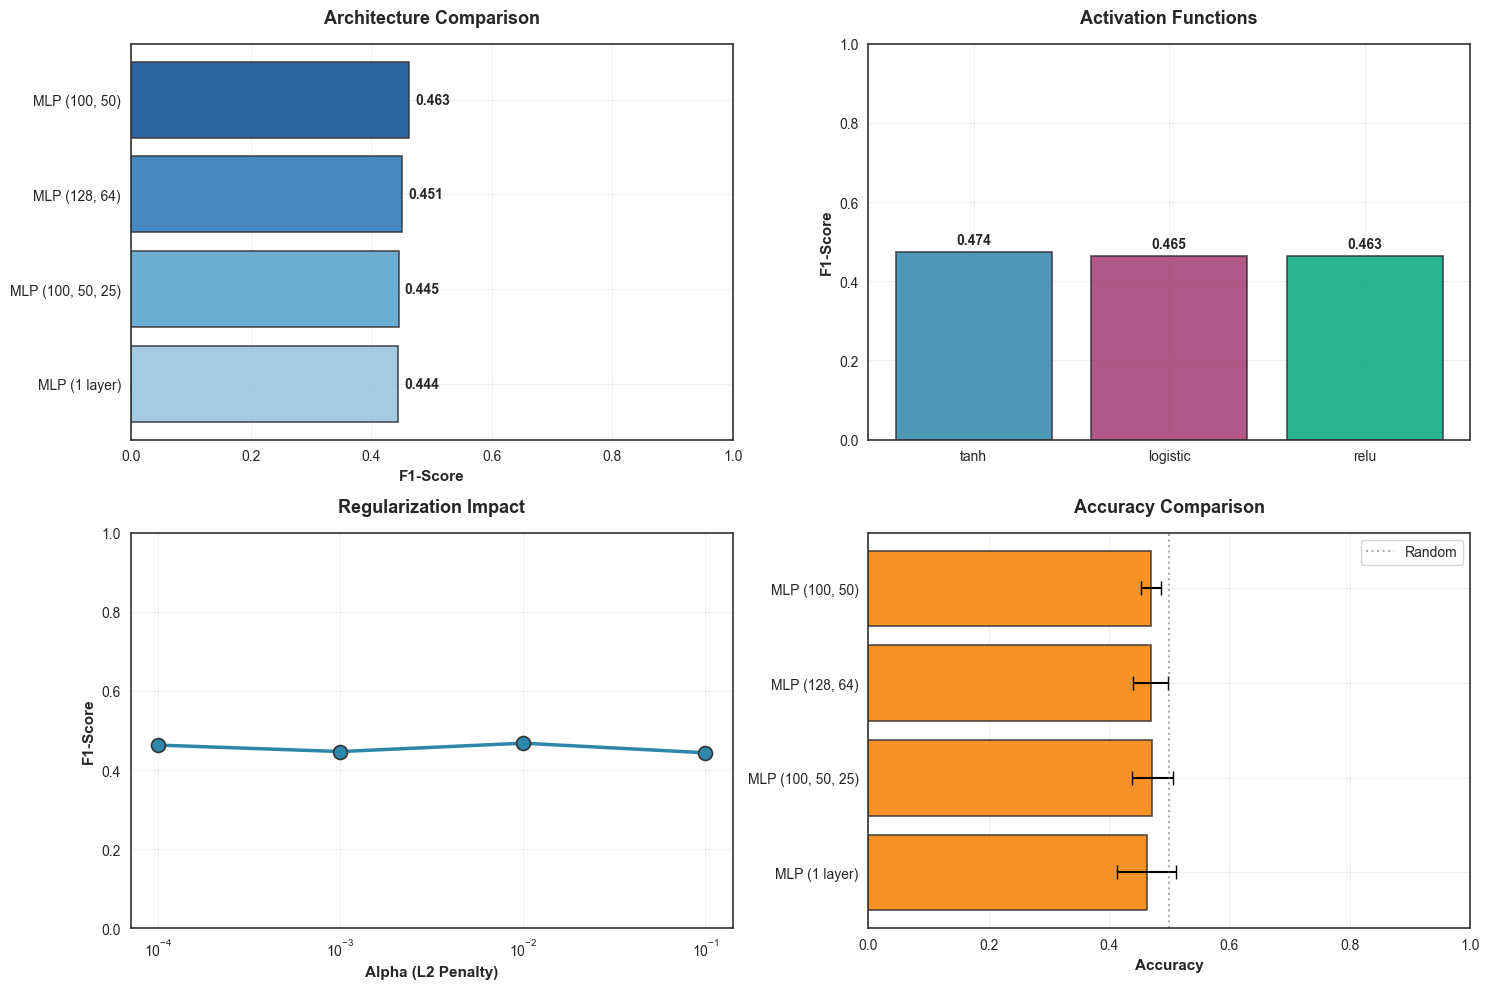

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

mlp_sorted = mlp_df.sort_values('f1', ascending=True)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(mlp_sorted)))

axes[0, 0].barh(mlp_sorted['name'], mlp_sorted['f1'], color=colors, 
                edgecolor='#333333', linewidth=1.2, alpha=0.85)
axes[0, 0].set_xlabel('F1-Score', fontweight='bold')
axes[0, 0].set_title('Architecture Comparison', fontweight='bold', fontsize=13, pad=15)
axes[0, 0].set_xlim([0, 1])
axes[0, 0].grid(axis='x', alpha=0.3)

for i, (name, f1) in enumerate(zip(mlp_sorted['name'], mlp_sorted['f1'])):
    axes[0, 0].text(f1 + 0.01, i, f'{f1:.3f}', va='center', fontweight='bold')

activation_colors = [COLOR_PALETTE['primary'], COLOR_PALETTE['secondary'], COLOR_PALETTE['success']]
activation_sorted = activation_df.sort_values('f1', ascending=False)
axes[0, 1].bar(activation_sorted['activation'], activation_sorted['f1'],
               color=activation_colors, alpha=0.85, 
               edgecolor='#333333', linewidth=1.2)
axes[0, 1].set_ylabel('F1-Score', fontweight='bold')
axes[0, 1].set_title('Activation Functions', fontweight='bold', fontsize=13, pad=15)
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(axis='y', alpha=0.3)

for i, (act, f1) in enumerate(zip(activation_sorted['activation'], activation_sorted['f1'])):
    axes[0, 1].text(i, f1 + 0.02, f'{f1:.3f}', ha='center', fontweight='bold')

axes[1, 0].plot(reg_df['alpha'], reg_df['f1'], 'o-', linewidth=2.5, 
                markersize=10, color=COLOR_PALETTE['primary'], 
                markeredgecolor='#333333', markeredgewidth=1.2)
axes[1, 0].set_xscale('log')
axes[1, 0].set_xlabel('Alpha (L2 Penalty)', fontweight='bold')
axes[1, 0].set_ylabel('F1-Score', fontweight='bold')
axes[1, 0].set_title('Regularization Impact', fontweight='bold', fontsize=13, pad=15)
axes[1, 0].grid(alpha=0.3)
axes[1, 0].set_ylim([0, 1])

axes[1, 1].barh(mlp_sorted['name'], mlp_sorted['accuracy'], 
                xerr=mlp_sorted['std'], capsize=5,
                color=COLOR_PALETTE['warning'], alpha=0.85, 
                edgecolor='#333333', linewidth=1.2)
axes[1, 1].set_xlabel('Accuracy', fontweight='bold')
axes[1, 1].set_title('Accuracy Comparison', fontweight='bold', fontsize=13, pad=15)
axes[1, 1].set_xlim([0, 1])
axes[1, 1].grid(axis='x', alpha=0.3)
axes[1, 1].axvline(x=0.5, color=COLOR_PALETTE['neutral'], linestyle=':', alpha=0.5, linewidth=1.5, label='Random')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('charts/mlp_analysis.png', dpi=300, bbox_inches='tight')
print("Saved to charts/mlp_analysis.png")
plt.show()